In [ ]:

from google.colab import drive
drive.mount('/content/drive')

In [1]:
!git clone https://github.com/pals-ucb/privacy-ner-att.git



Cloning into 'privacy-ner-att'...
remote: Enumerating objects: 171, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 171 (delta 19), reused 19 (delta 6), pack-reused 123 (from 1)
Receiving objects: 100% (171/171), 137.73 MiB | 15.40 MiB/s, done.
Resolving deltas: 100% (69/69), done.


In [2]:
!pip install -r privacy-ner-att/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Require

In [3]:
!cd privacy-ner-att/datasets/; unzip hf_privacy_ner_cleaned.zip

Archive:  hf_privacy_ner_cleaned.zip
   creating: hf_privacy_ner_cleaned/
  inflating: hf_privacy_ner_cleaned/dataset_dict.json  
   creating: hf_privacy_ner_cleaned/test/
  inflating: hf_privacy_ner_cleaned/test/state.json  
  inflating: hf_privacy_ner_cleaned/test/cache-0bb6367ca4f1e00a.arrow  
  inflating: hf_privacy_ner_cleaned/test/cache-d0ed1cd06ce6f914.arrow  
  inflating: hf_privacy_ner_cleaned/test/dataset_info.json  
  inflating: hf_privacy_ner_cleaned/test/data-00000-of-00001.arrow  
  inflating: hf_privacy_ner_cleaned/test/cache-e4faa0f52c4ad25f.arrow  
   creating: hf_privacy_ner_cleaned/train/
  inflating: hf_privacy_ner_cleaned/train/state.json  
  inflating: hf_privacy_ner_cleaned/train/cache-26a4635317525fea.arrow  
  inflating: hf_privacy_ner_cleaned/train/cache-01e42c1b16071b32.arrow  
  inflating: hf_privacy_ner_cleaned/train/dataset_info.json  
  inflating: hf_privacy_ner_cleaned/train/data-00000-of-00001.arrow  
  inflating: hf_privacy_ner_cleaned/train/cache-2f10

In [5]:
!pip install datasets

  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached multiprocess-0.70.16-py311-none-any.whl.metadata (7.2 kB)
  Using cached fsspec-2024.12.0-py3-none-any.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; plat

In [22]:
from datasets import load_from_disk
dataset = load_from_disk("privacy-ner-att/datasets/hf_privacy_ner_cleaned")
test_dataset = dataset['test']


In [29]:
from transformers import pipeline
from tqdm import tqdm
from sklearn.metrics import classification_report


Device set to use cpu
100%|██████████| 2420/2420 [1:15:49<00:00,  1.88s/it]


Predictions saved to 'privacy_predictions.csv'.
Accuracy: 76.40%


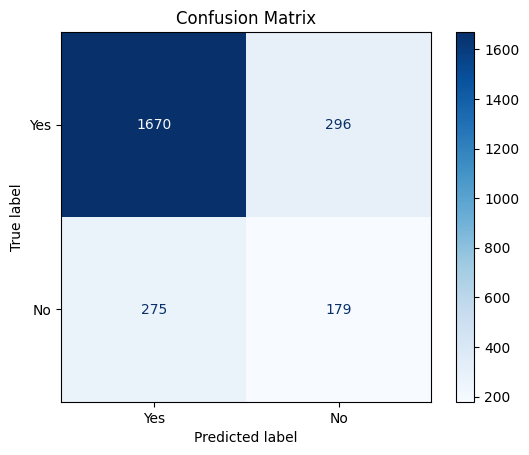

In [60]:
from transformers import pipeline
from datasets import load_from_disk
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load dataset from disk
dataset = load_from_disk("privacy-ner-att/datasets/hf_privacy_ner_cleaned")
test_dataset = dataset["test"]

# Load zero-shot classification model
llm = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device_map="auto"
)

# Candidate labels
candidate_labels = [
    "contains personally identifiable information",
    "does not contain personally identifiable information"
]

# Format prompt (zero-shot uses raw text)
def format_prompt(text):
    return f"{text}"

# Store detailed results
results = []

# Loop through the full dataset
for record in tqdm(test_dataset):
    prompt = format_prompt(record["text"])
    output = llm(prompt, candidate_labels=candidate_labels)

    top_label = output["labels"][0]
    pred = "Yes" if top_label == "contains personally identifiable information" else "No"
    true = "Yes" if record["privacy_class_label"] == 1 else "No"

    results.append({
        "text": record["text"],
        "true_label": true,
        "predicted_label": pred,
        "score": output["scores"][0]  # confidence for top label
    })

# Convert to DataFrame and save
df_results = pd.DataFrame(results)
df_results.to_csv("privacy_predictions.csv", index=False)
print("Predictions saved to 'privacy_predictions.csv'.")

# Accuracy
accuracy = accuracy_score(df_results["true_label"], df_results["predicted_label"])
print(f"Accuracy: {accuracy:.2%}")

# Confusion Matrix
cm = confusion_matrix(df_results["true_label"], df_results["predicted_label"], labels=["Yes", "No"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Yes", "No"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [79]:
true_labels=df_results['true_label'].tolist()
predictions=df_results['predicted_label'].tolist()

# Evaluate performance
print(classification_report(true_labels, predictions))

              precision    recall  f1-score   support

          No       0.38      0.39      0.39       454
         Yes       0.86      0.85      0.85      1966

    accuracy                           0.76      2420
   macro avg       0.62      0.62      0.62      2420
weighted avg       0.77      0.76      0.77      2420



In [77]:
df_results.to_csv("/content/drive/MyDrive/datasci-266/baseline_no_training_privacy_model.csv")